### Exercise: Planning a telescope observation



In [64]:
import numpy as np
import matplotlib.pyplot as plt

#N iteraions
N = 15000
burn_in = 500

#trace
stati = np.zeros(N)
stati[0] = 0 

#markov-chain
for i in range(1, N):
    if stati[i-1] == 0: 
        stati[i] = np.random.choice([0, 1], p=[0.5, 0.5])
    else:
        stati[i] = np.random.choice([0, 1], p=[0.1, 0.9])

#montecarlo integration (sum)
sunny_days_cumulati = np.cumsum(stati)
giorni_trascorsi = np.arange(1, N + 1)

#stationary chain, trace is the cumulative mean
p_clear_trace = sunny_days_cumulati / giorni_trascorsi
p_clear_trace_post_burn = p_clear_trace[burn_in:]

Parameter estimation and Credibility Intervals

In [65]:
def calcola_statistiche(dati, nome_dataset):
    mediana = np.median(dati)
    p16 = np.percentile(dati, 16)
    p25 = np.percentile(dati, 25)
    p75 = np.percentile(dati, 75)
    p84 = np.percentile(dati, 84)
    err_inf = mediana - p16
    err_sup = p84 - mediana
    print(f"{nome_dataset}")
    print(f"p(clear) stimato = {mediana:.4f} (+{err_sup:.4f} / -{err_inf:.4f})")
    print(f"Range interquartile (25%-75%): [{p25:.4f}, {p75:.4f}]\n")

calcola_statistiche(p_clear_trace, "DATASET COMPLETO (Con Burn-in)")
calcola_statistiche(p_clear_trace_post_burn, "DATASET RIPULITO (Post Burn-in)")

DATASET COMPLETO (Con Burn-in)
p(clear) stimato = 0.8260 (+0.0018 / -0.0029)
Range interquartile (25%-75%): [0.8240, 0.8271]

DATASET RIPULITO (Post Burn-in)
p(clear) stimato = 0.8260 (+0.0016 / -0.0029)
Range interquartile (25%-75%): [0.8239, 0.8270]



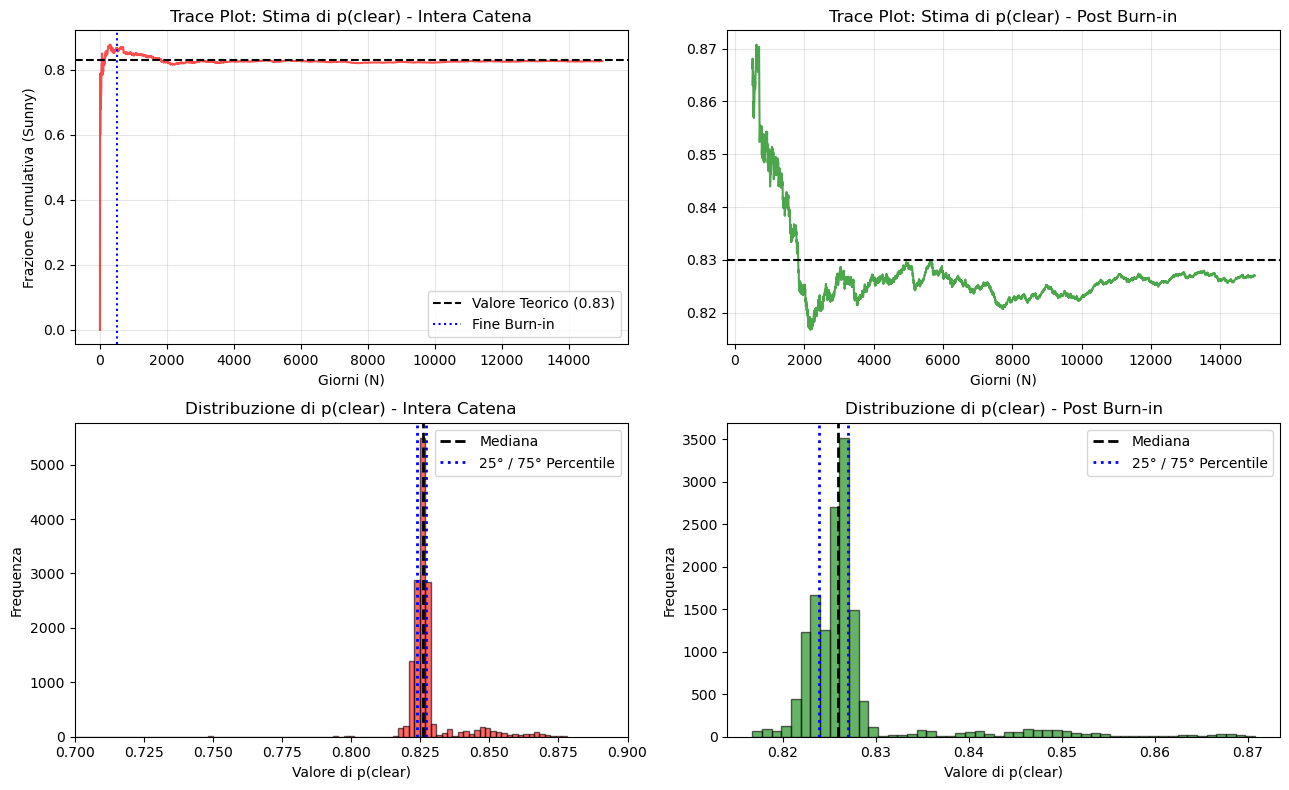

In [66]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

ax[0, 0].plot(giorni_trascorsi, p_clear_trace, color='red', alpha=0.7)
ax[0, 0].axhline(0.83, color='black', linestyle='--', label='Valore Teorico (0.83)')
ax[0, 0].axvline(burn_in, color='blue', linestyle=':', label='Fine Burn-in')
ax[0, 0].set_title('Trace Plot: Stima di p(clear) - Intera Catena')
ax[0, 0].set_xlabel('Giorni (N)')
ax[0, 0].set_ylabel('Frazione Cumulativa (Sunny)')
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.3)

# Trace plot - Post Burn-in
ax[0, 1].plot(giorni_trascorsi[burn_in:], p_clear_trace_post_burn, color='green', alpha=0.7)
ax[0, 1].axhline(0.83, color='black', linestyle='--', label='Valore Teorico (0.83)')
ax[0, 1].set_title('Trace Plot: Stima di p(clear) - Post Burn-in')
ax[0, 1].set_xlabel('Giorni (N)')
ax[0, 1].grid(True, alpha=0.3)

p25_full, p75_full = np.percentile(p_clear_trace, [25, 75])
p25_post, p75_post = np.percentile(p_clear_trace_post_burn, [25, 75])

ax[1, 0].hist(p_clear_trace, bins='scott', color='red', alpha=0.6, edgecolor='black')
ax[1, 0].axvline(np.median(p_clear_trace), color='black', linestyle='dashed', linewidth=2, label='Mediana')
ax[1, 0].axvline(p25_full, color='blue', linestyle='dotted', linewidth=2, label='25° / 75° Percentile')
ax[1, 0].axvline(p75_full, color='blue', linestyle='dotted', linewidth=2)
ax[1, 0].set_title('Distribuzione di p(clear) - Intera Catena')
ax[1, 0].set_xlabel('Valore di p(clear)')
ax[1, 0].set_ylabel('Frequenza')
ax[1, 0].set_xlim(0.7,0.9)
ax[1, 0].legend()

ax[1, 1].hist(p_clear_trace_post_burn, bins='scott', color='green', alpha=0.6, edgecolor='black')
ax[1, 1].axvline(np.median(p_clear_trace_post_burn), color='black', linestyle='dashed', linewidth=2, label='Mediana')
ax[1, 1].axvline(p25_post, color='blue', linestyle='dotted', linewidth=2, label='25° / 75° Percentile')
ax[1, 1].axvline(p75_post, color='blue', linestyle='dotted', linewidth=2)
ax[1, 1].set_title('Distribuzione di p(clear) - Post Burn-in')
ax[1, 1].set_xlabel('Valore di p(clear)')
ax[1, 1].set_ylabel('Frequenza')
ax[1, 1].legend()

plt.tight_layout()
plt.show()